# ✅ Solutions — Module 3 — Probability Distributions

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

### ✍️ Exercise 3.1 — *Binomial*: Design an acceptance-sampling plan (Incoming goods inspection)

Your company buys resistors in lots of 10,000. Testing every part is too expensive, so QA inspects a random sample of $n$ parts and **accepts the lot if at most $c$ are defective**. Current plan: $n = 80$, $c = 2$.

**Tasks**
1. What is the probability of accepting a lot with a true defect rate of 1 % (a *good* lot)? Of 5 % (a *bad* lot)?
2. Plot the **operating-characteristic (OC) curve**: P(accept) as a function of the true defect rate from 0 to 12 %.
3. The contract demands: good lots (1 %) are accepted with probability ≥ 95 % (*producer's risk* ≤ 5 %), bad lots (5 %) with probability ≤ 10 % (*consumer's risk*). Does the current plan comply? Find the plan with the **smallest $n$** that does.
4. Why is the binomial only an approximation here, and why is it a good one?

1) current plan (n=80, c=2): P(accept | 1 %) = 0.953,   P(accept | 5 %) = 0.231
3) smallest compliant plan: n = 132, c = 3:  P(accept | 1 %) = 0.956,  P(accept | 5 %) = 0.099


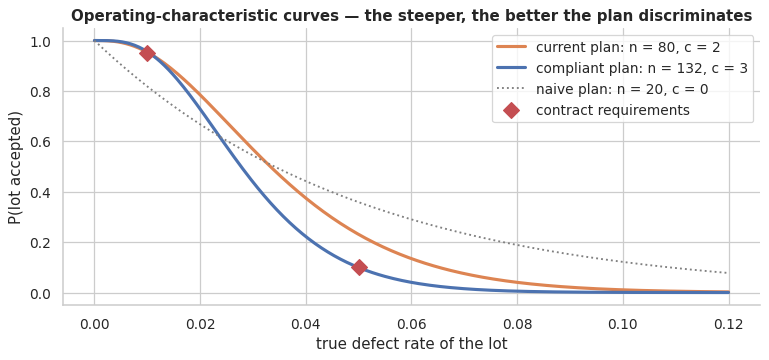

In [2]:
p_acc = lambda n, c, p: stats.binom.cdf(c, n, p)
print(f"1) current plan (n=80, c=2): P(accept | 1 %) = {p_acc(80, 2, .01):.3f},   P(accept | 5 %) = {p_acc(80, 2, .05):.3f}")

best = next((n, c) for n in range(10, 600) for c in range(0, 15) if p_acc(n, c, .01) >= .95 and p_acc(n, c, .05) <= .10)
n_b, c_b = best
print(f"3) smallest compliant plan: n = {n_b}, c = {c_b}:  P(accept | 1 %) = {p_acc(n_b, c_b, .01):.3f},  P(accept | 5 %) = {p_acc(n_b, c_b, .05):.3f}")

p = np.linspace(0, .12, 300); fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(p, p_acc(80, 2, p), lw=2.5, color=C[1], label="current plan: n = 80, c = 2"); ax.plot(p, p_acc(n_b, c_b, p), lw=2.5, color=C[0], label=f"compliant plan: n = {n_b}, c = {c_b}")
ax.plot(p, p_acc(20, 0, p), lw=1.5, ls=":", color="grey", label="naive plan: n = 20, c = 0")
ax.scatter([.01, .05], [.95, .10], color=C[3], zorder=4, s=80, marker="D", label="contract requirements")
ax.set(xlabel="true defect rate of the lot", ylabel="P(lot accepted)", title="Operating-characteristic curves — the steeper, the better the plan discriminates"); ax.legend(); plt.show()

**Interpretation.** The current plan protects the *producer* (good lots are accepted ≈ 95 % of the time) but not the *consumer*: a bad lot with 5 % defects still slips through with probability ≈ 23 %. A compliant plan needs a noticeably larger sample (n ≈ 130, c = 3) — discrimination costs sample size. The "naive" plan *n = 20, c = 0* looks strict but has a flat OC curve: it rejects 18 % of good lots and still accepts 36 % of bad ones.

**Binomial vs. reality:** sampling is *without replacement* from a finite lot, so the exact model is hypergeometric. Because the sample is only ≈ 1 % of the lot, drawing one part hardly changes the composition of the rest and the binomial is an excellent approximation (rule of thumb: sample < 10 % of the population).

### ✍️ Exercise 3.2 — *Poisson*: Staffing a call centre (Operations)

A support hotline logged the number of incoming calls for 500 peak hours (`calls`). One agent can handle 6 calls per hour.

**Tasks**
1. Estimate $\lambda$. Check the Poisson assumption: compare mean and variance, and overlay the Poisson PMF on the empirical distribution.
2. What is the probability of more than 24 calls in an hour (the capacity of 4 agents)?
3. Management wants the probability that calls exceed capacity to be **at most 5 %**. How many agents are needed?
4. What is the probability that **no call arrives for 10 minutes** (so an agent can take a short break)? Which distribution do you need?

In [3]:
g = np.random.default_rng(302)
calls = pd.Series(g.poisson(18.3, 500), name="calls_per_hour")
calls.describe().round(2)

count    500.00
mean      18.31
std        4.30
min        8.00
25%       15.00
50%       18.00
75%       21.00
max       31.00
Name: calls_per_hour, dtype: float64

1) λ̂ = 18.31 calls/hour,  variance = 18.49  (ratio var/mean = 1.01; ≈ 1 supports the Poisson model)
2) P(X > 24) = 0.079  -> with 4 agents roughly every 13th peak hour is overloaded
3) 95 % quantile = 26 calls  ->  5 agents (capacity 30),  P(overload) = 0.004
4) P(no call in 10 min) = exp(-λ·10/60) = 0.047   [= expon.sf(10, scale=60/λ) = 0.047]


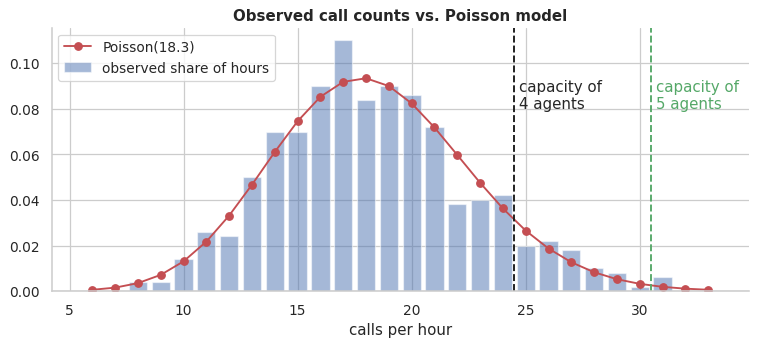

In [4]:
lam = calls.mean()
print(f"1) λ̂ = {lam:.2f} calls/hour,  variance = {calls.var():.2f}  (ratio var/mean = {calls.var() / lam:.2f}; ≈ 1 supports the Poisson model)")
print(f"2) P(X > 24) = {stats.poisson.sf(24, lam):.3f}  -> with 4 agents roughly every {1 / stats.poisson.sf(24, lam):.0f}th peak hour is overloaded")
cap = stats.poisson.ppf(.95, lam); agents = int(np.ceil(cap / 6))
print(f"3) 95 % quantile = {cap:.0f} calls  ->  {agents} agents (capacity {agents * 6}),  P(overload) = {stats.poisson.sf(agents * 6, lam):.3f}")
print(f"4) P(no call in 10 min) = exp(-λ·10/60) = {np.exp(-lam / 6):.3f}   [= expon.sf(10, scale=60/λ) = {stats.expon.sf(10, scale=60 / lam):.3f}]")

k = np.arange(calls.min() - 2, calls.max() + 3); fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(k, [(calls == i).mean() for i in k], color=C[0], alpha=.5, label="observed share of hours"); ax.plot(k, stats.poisson.pmf(k, lam), "o-", color=C[3], label=f"Poisson({lam:.1f})")
ax.axvline(24.5, color="k", ls="--"); ax.text(24.7, .08, "capacity of\n4 agents"); ax.axvline(agents * 6 + .5, color=C[2], ls="--"); ax.text(agents * 6 + .7, .08, f"capacity of\n{agents} agents", color=C[2])
ax.set(xlabel="calls per hour", title="Observed call counts vs. Poisson model"); ax.legend(loc="upper left"); plt.show()

**Interpretation.** Mean ≈ variance and the PMF overlay fits well, so the Poisson model is adequate. With 4 agents (capacity 24) about 8 % of peak hours are overloaded; the 95 % quantile is 26 calls, so **5 agents** (capacity 30) are required, which pushes the overload probability below 1 %.

Task 4 switches from *counts* to *waiting times*: in a Poisson process the gap between events is exponential with mean $60/\lambda \approx 3.3$ minutes, so a 10-minute silence happens only ≈ 5 % of the time. (In practice call rates vary over the day — a model with a time-varying $\lambda$ would be the next refinement.)

### ✍️ Exercise 3.3 — *Normal*: How many shafts are out of tolerance? (Manufacturing / Six Sigma)

A lathe produces shafts with specified diameter **25.00 ± 0.05 mm**. Measurements show the process is normally distributed with mean 25.01 mm and standard deviation 0.02 mm.

**Tasks**
1. What fraction of shafts is out of spec? Express it in **ppm** (parts per million) and split it into "too thick" and "too thin". Visualise.
2. How much would re-centring the process at 25.00 mm help?
3. With a centred process, which standard deviation is needed to reach at most **100 ppm**?
4. Compute the capability indices $C_p = \frac{USL-LSL}{6\sigma}$ and $C_{pk} = \frac{\min(USL-\mu,\ \mu-LSL)}{3\sigma}$ for the current process. Industry usually demands $C_{pk} \ge 1.33$.

1) current : too thin 1,350 ppm + too thick 22,750 ppm = 24,100 ppm (2.41 %)
2) centred : 12,419 ppm  -> re-centring alone removes 48% of the scrap
3) σ needed for 100 ppm (centred): 0.0129 mm  (tolerance = ±3.89 σ)
4) Cp = 0.83,  Cpk = 0.67


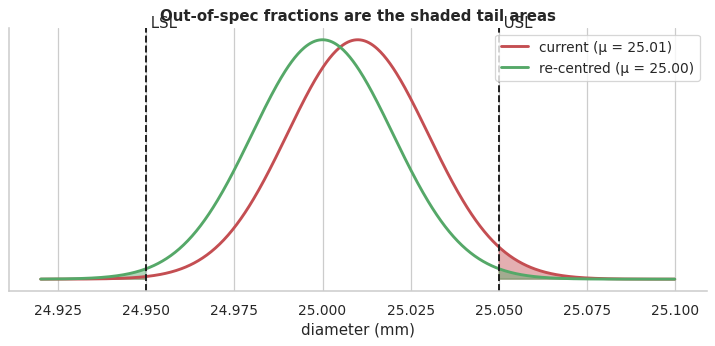

In [5]:
LSL, USL = 24.95, 25.05
def out_ppm(mu, sd): return stats.norm.cdf(LSL, mu, sd) * 1e6, stats.norm.sf(USL, mu, sd) * 1e6
lo, hi = out_ppm(25.01, .02); lo_c, hi_c = out_ppm(25.00, .02)
print(f"1) current : too thin {lo:,.0f} ppm + too thick {hi:,.0f} ppm = {lo + hi:,.0f} ppm ({(lo + hi) / 1e4:.2f} %)")
print(f"2) centred : {lo_c + hi_c:,.0f} ppm  -> re-centring alone removes {1 - (lo_c + hi_c) / (lo + hi):.0%} of the scrap")
sd_needed = .05 / stats.norm.isf(100e-6 / 2)                 # 50 ppm in each tail
print(f"3) σ needed for 100 ppm (centred): {sd_needed:.4f} mm  (tolerance = ±{.05 / sd_needed:.2f} σ)")
print(f"4) Cp = {(USL - LSL) / (6 * .02):.2f},  Cpk = {min(USL - 25.01, 25.01 - LSL) / (3 * .02):.2f}")

x = np.linspace(24.92, 25.10, 600); fig, ax = plt.subplots(figsize=(10, 3.8))
for mu, col, name in [(25.01, C[3], "current (μ = 25.01)"), (25.00, C[2], "re-centred (μ = 25.00)")]:
    y = stats.norm.pdf(x, mu, .02); ax.plot(x, y, color=col, lw=2.3, label=name); ax.fill_between(x, y, where=(x < LSL) | (x > USL), color=col, alpha=.45)
ax.axvline(LSL, color="k", ls="--"); ax.axvline(USL, color="k", ls="--"); ax.text(LSL, 21, " LSL"); ax.text(USL, 21, " USL")
ax.set(xlabel="diameter (mm)", yticks=[], title="Out-of-spec fractions are the shaded tail areas"); ax.legend(); plt.show()

**Interpretation.** The small 0.01 mm offset is expensive: ≈ 2.4 % scrap, almost all of it "too thick" because the upper limit is only 2σ away. Re-centring (usually a cheap machine adjustment) halves scrap to ≈ 1.2 %. Reaching 100 ppm requires cutting σ from 0.020 to ≈ 0.013 mm (tolerance ≈ ±3.9σ) — typically an expensive process improvement. $C_p = 0.83$ and $C_{pk} = 0.67$ are far below 1.33: this process is *not capable*.

**Caveat:** ppm figures depend on the extreme tails of the normal model — precisely where it is least trustworthy. Always verify normality (Q–Q plot) before quoting ppm numbers.

### ✍️ Exercise 3.4 — *Exponential*: Pump failures in a chemical plant (Reliability)

A pump type fails at random with a **mean time between failures (MTBF) of 400 days**; lifetimes are modelled as exponential.

**Tasks**
1. What is the probability that a new pump runs a full year (365 days) without failure? What is its *median* lifetime, and why is it so much shorter than the mean?
2. A pump has already run 300 days. What is the probability that it survives another 100 days? Compare with a new pump.
3. The plant runs **5 such pumps** independently. What is the probability of at least one failure within the next 30 days? How many failures per year should the maintenance team expect, and what is the probability of more than 7?
4. Verify 1–3 with a simulation. When is the exponential model inappropriate for pumps?

1) P(T > 365) = 0.402 | median = 277 days = MTBF·ln 2   (right-skewed: few very long lives pull the mean up)
2) P(T > 400 | T > 300) = 0.779  =  P(T > 100) for a new pump = 0.779   -> memoryless
3) P(≥1 failure among 5 pumps in 30 d) = 0.313 | failures/year ~ Poisson(4.56):  P(more than 7) = 0.092
4) simulation: P(T>365) = 0.402 | P(T>400|T>300) = 0.779 | P(≥1 of 5 fails in 30 d) = 0.311


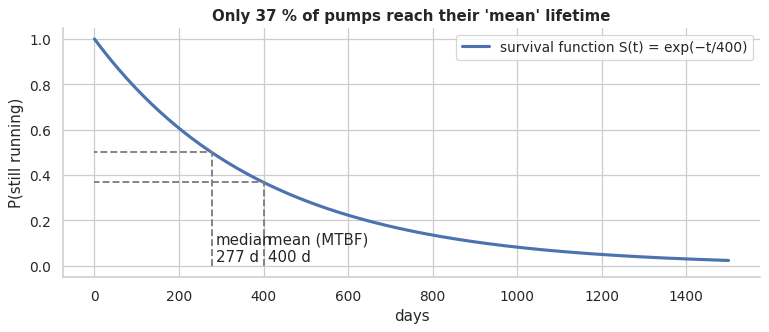

In [6]:
mtbf = 400; T = stats.expon(scale=mtbf)
print(f"1) P(T > 365) = {T.sf(365):.3f} | median = {T.median():.0f} days = MTBF·ln 2   (right-skewed: few very long lives pull the mean up)")
print(f"2) P(T > 400 | T > 300) = {T.sf(400) / T.sf(300):.3f}  =  P(T > 100) for a new pump = {T.sf(100):.3f}   -> memoryless")
lam_year = 5 * 365 / mtbf
print(f"3) P(≥1 failure among 5 pumps in 30 d) = {1 - T.sf(30) ** 5:.3f} | failures/year ~ Poisson({lam_year:.2f}):  P(more than 7) = {stats.poisson.sf(7, lam_year):.3f}")

g = np.random.default_rng(4); life = g.exponential(mtbf, (200_000, 5))
print(f"4) simulation: P(T>365) = {(life[:, 0] > 365).mean():.3f} | P(T>400|T>300) = {(life[:, 0] > 400).sum() / (life[:, 0] > 300).sum():.3f} | P(≥1 of 5 fails in 30 d) = {(life.min(axis=1) < 30).mean():.3f}")

t = np.linspace(0, 1500, 400); fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, T.sf(t), lw=2.5, color=C[0], label="survival function S(t) = exp(−t/400)")
for d, lab in [(T.median(), "median"), (mtbf, "mean (MTBF)")]: ax.plot([d, d, 0], [0, T.sf(d), T.sf(d)], ls="--", color="grey"); ax.text(d + 10, .02, f"{lab}\n{d:.0f} d")
ax.set(xlabel="days", ylabel="P(still running)", title="Only 37 % of pumps reach their 'mean' lifetime"); ax.legend(); plt.show()

**Interpretation.** Only ≈ 40 % of pumps survive a year although the *mean* life exceeds a year; half have failed after 277 days. An MTBF is **not** a guaranteed lifetime: only $e^{-1} \approx 37\,\%$ of units reach it. Memorylessness means age is irrelevant — preventive replacement of exponential components is pointless. With five pumps the team should plan for ≈ 4.6 failures per year, and keep spares for the ≈ 9 % chance of more than seven.

**When is this wrong?** Mechanical pumps *wear out*: the failure rate rises with age (bathtub curve). Then a Weibull model with shape > 1 is appropriate, survival after 300 days is *lower* than for a new pump, and preventive maintenance becomes worthwhile.

### ✍️ Exercise 3.5 — *Fitting & tail risk*: How big can a claim get? (Insurance / risk management)

An insurer has 2,000 historical claim sizes (€) for a liability product. The actuary needs (a) the probability that a single claim exceeds **€50,000** and (b) the **99.5 % quantile** (used for solvency capital).

**Tasks**
1. Explore the data: histogram on a linear and on a log scale, skewness, mean vs. median.
2. Fit an **exponential**, a **gamma** and a **lognormal** distribution (fix `floc=0`). Compare log-likelihood and AIC.
3. Draw Q–Q plots of the data against each fitted model (log–log axes help).
4. Report P(claim > €50k) and the 99.5 % quantile under each model and compare with the empirical values. What is the business lesson?

In [7]:
g = np.random.default_rng(305)
claims = np.round(g.lognormal(mean=8.2, sigma=1.15, size=2000), 2)
pd.Series(claims).describe().round(0)

count      2000.0
mean       7160.0
std       11395.0
min          37.0
25%        1669.0
50%        3634.0
75%        7965.0
max      174869.0
dtype: float64

mean 7,160 € | median 3,634 € | skewness 5.5 | max 174,869 €


,logL,AIC,P(X > 50k),99.5 % quantile
model,,,,
exponential,"-19,753","39,507",0.0928%,"37,938 €"
gamma,"-19,741","39,486",0.1570%,"40,738 €"
lognormal,"-19,531","39,067",1.1456%,"70,623 €"
empirical,—,—,1.3500%,"70,135 €"


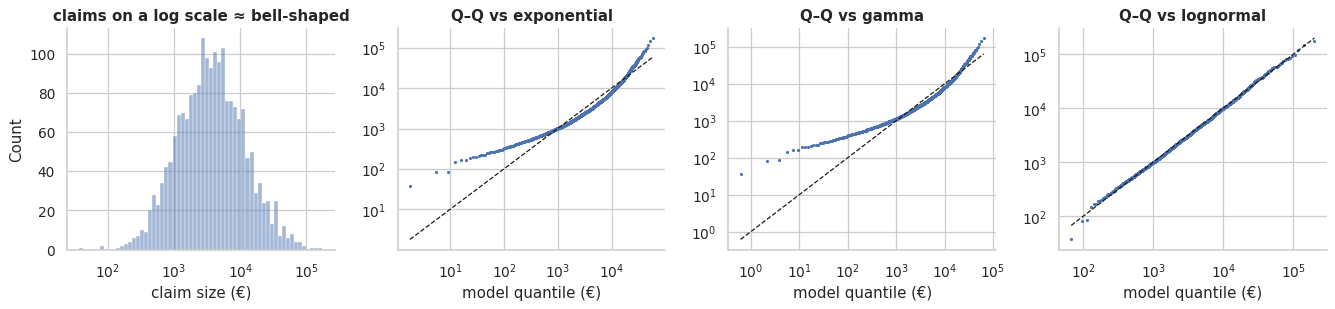

In [8]:
print(f"mean {claims.mean():,.0f} € | median {np.median(claims):,.0f} € | skewness {stats.skew(claims):.1f} | max {claims.max():,.0f} €")
cands = {"exponential": (stats.expon, 1), "gamma": (stats.gamma, 2), "lognormal": (stats.lognorm, 2)}
fits, rows = {}, []
for name, (dist, k) in cands.items():
    f = dist(*dist.fit(claims, floc=0)); fits[name] = f; ll = f.logpdf(claims).sum()
    rows.append({"model": name, "logL": ll, "AIC": 2 * k - 2 * ll, "P(X > 50k)": f.sf(50_000), "99.5 % quantile": f.ppf(.995)})
rows.append({"model": "empirical", "P(X > 50k)": (claims > 50_000).mean(), "99.5 % quantile": np.quantile(claims, .995)})
display(pd.DataFrame(rows).set_index("model").style.format({"logL": "{:,.0f}", "AIC": "{:,.0f}", "P(X > 50k)": "{:.4%}", "99.5 % quantile": "{:,.0f} €"}, na_rep="—"))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
sns.histplot(claims, bins=60, log_scale=True, ax=axes[0], color=C[0], alpha=.5); axes[0].set(title="claims on a log scale ≈ bell-shaped", xlabel="claim size (€)")
probs = (np.arange(1, len(claims) + 1) - .5) / len(claims)
for ax, (name, f) in zip(axes[1:], fits.items()):
    theo = f.ppf(probs); ax.loglog(theo, np.sort(claims), ".", ms=3, color=C[0]); ax.loglog(theo, theo, "k--", lw=1); ax.set(title=f"Q–Q vs {name}", xlabel="model quantile (€)")
plt.tight_layout(); plt.show()

**Interpretation.** The data is extremely right-skewed (mean ≈ 2× median). On a log scale the histogram is bell-shaped — the fingerprint of a lognormal, which also wins clearly on AIC and is the only model whose Q–Q plot is straight.

The **business lesson is in the tail**: all three models have similar means, yet the exponential and gamma fits put the probability of a claim above €50k at roughly **a tenth** of what the data (≈ 1.4 %) and the lognormal (≈ 1.1 %) show, and they underestimate the 99.5 % quantile by about €30,000 (≈ €40k instead of ≈ €70k). An insurer reserving capital with a thin-tailed model would be badly under-capitalised. *Model choice matters most exactly where you have the least data — always check the tail fit, not just the bulk.*